# Scryfall Card OCR Fine-Tuning

This notebook explores the `card_image_text_manifest.jsonl` dataset and fine-tunes a TrOCR-based OCR model with LoRA adapters for structured MTG card text extraction.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Subset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

workspace_root = Path.cwd()
if workspace_root.name == "notebooks":
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from src.card_ocr import CardOCRFineTuner, CardOCRTrainingConfig, load_manifest_records, summarize_manifest
from src.card_ocr.augmentations import CardOCRAugmenter
from src.card_ocr.config import OCRAugmentationConfig

/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
manifest_path = Path("../data/card_image_text_manifest.jsonl")
records = load_manifest_records(manifest_path, skip_missing_images=False)
summary = summarize_manifest(records)
summary

{'num_records': 8447, 'split_counts': {'train': 6717, 'val': 1680, 'test': 50}}

In [3]:
df = pd.DataFrame(records)
df[["card_name", "split", "image_path"]].head()

,card_name,split,image_path
0,Ascended Lawmage,train,/Users/nickcruickshank/Projects/scryfall-llm-s...
1,Kami of Transmutation,train,/Users/nickcruickshank/Projects/scryfall-llm-s...
2,Felidar Umbra,train,/Users/nickcruickshank/Projects/scryfall-llm-s...
3,Chainbreaker,train,/Users/nickcruickshank/Projects/scryfall-llm-s...
4,"Tymaret, the Murder King",train,/Users/nickcruickshank/Projects/scryfall-llm-s...


In [4]:
sample_record = next(record for record in records if Path(record["image_path"]).exists())
sample_image = Image.open(sample_record["image_path"]).convert("RGB")
sample_record["card_name"], sample_image.size

('Ascended Lawmage', (745, 1040))

In [5]:
config = CardOCRTrainingConfig(
    manifest_path=str(manifest_path),
    base_model_name="microsoft/trocr-small-printed",
    output_dir="../models/scryfall-card-ocr",
    image_height=576,
    image_width=800,
    interpolate_pos_encoding=True,
    max_target_length=512,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=8,
    learning_rate=2e-4,
)
config

CardOCRTrainingConfig(manifest_path='../data/card_image_text_manifest.jsonl', base_model_name='microsoft/trocr-small-printed', output_dir='../models/scryfall-card-ocr', image_height=576, image_width=800, interpolate_pos_encoding=True, max_target_length=512, per_device_train_batch_size=2, per_device_eval_batch_size=2, gradient_accumulation_steps=4, num_train_epochs=8, learning_rate=0.0002, weight_decay=0.01, warmup_ratio=0.1, logging_steps=10, save_total_limit=2, generation_max_length=512, generation_num_beams=1, gradient_checkpointing=True, dataloader_num_workers=0, early_stopping_patience=3, report_to='none', seed=42, use_fp16=True, use_bf16=False, skip_missing_images=True, train_split_name='train', eval_split_name='val', test_split_name='test', augmentations=OCRAugmentationConfig(rotation_degrees=10.0, rotation_probability=0.7, blur_probability=0.3, blur_radius_min=0.2, blur_radius_max=1.4, dilation_probability=0.2, erosion_probability=0.2, downscale_probability=0.3, downscale_min_sc

## Pre-Flight EDA

These checks help estimate target sequence length pressure and confirm the image dimensions coming from the Scryfall assets.

In [6]:
eda_processor = TrOCRProcessor.from_pretrained(config.base_model_name)
token_lengths = pd.Series(
    [len(eda_processor.tokenizer(record["target_text"]).input_ids) for record in records],
    name="target_token_length",
)
token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    8447.000000
mean       83.139221
std        23.254902
min        37.000000
50%        79.000000
90%       115.000000
95%       125.000000
99%       144.000000
max       384.000000
Name: target_token_length, dtype: float64

Examples over max_target_length=512: 0 / 8447


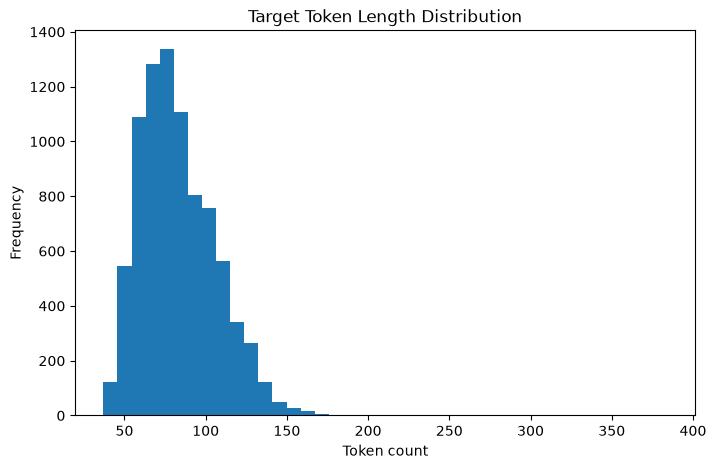

In [7]:
num_truncated = int((token_lengths > config.max_target_length).sum())
print(f"Examples over max_target_length={config.max_target_length}: {num_truncated} / {len(token_lengths)}")

ax = token_lengths.plot.hist(bins=40, figsize=(8, 5), title="Target Token Length Distribution")
ax.set_xlabel("Token count")
plt.show()

In [8]:
image_sizes = []
for record in records:
    image_path = Path(record["image_path"])
    if not image_path.exists():
        continue
    with Image.open(image_path) as image:
        width, height = image.size
    image_sizes.append({"width": width, "height": height, "aspect_ratio": width / height})

image_size_df = pd.DataFrame(image_sizes)
print(image_size_df[["width", "height"]].value_counts().head())
image_size_df.describe()

width  height
745    1040      8443
Name: count, dtype: int64


,width,height,aspect_ratio
count,8443.0,8443.0,8.443000e+03
mean,745.0,1040.0,7.163462e-01
std,0.0,0.0,1.110289e-16
min,745.0,1040.0,7.163462e-01
25%,745.0,1040.0,7.163462e-01
50%,745.0,1040.0,7.163462e-01
75%,745.0,1040.0,7.163462e-01
max,745.0,1040.0,7.163462e-01


## Augmentation Preview

These cells pick a random card image and visualize each augmentation independently, followed by one example of the full randomized augmentation pipeline.

In [9]:
preview_record = random.choice([record for record in records if Path(record["image_path"]).exists()])
preview_image = Image.open(preview_record["image_path"]).convert("RGB")
preview_record["card_name"], preview_image.size

('Frostpeak Yeti', (745, 1040))

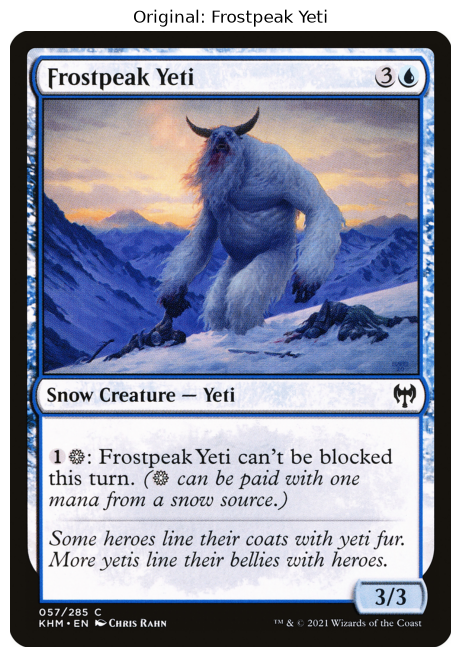

In [10]:
plt.figure(figsize=(6, 8))
plt.imshow(preview_image)
plt.title(f"Original: {preview_record['card_name']}")
plt.axis("off")
plt.show()

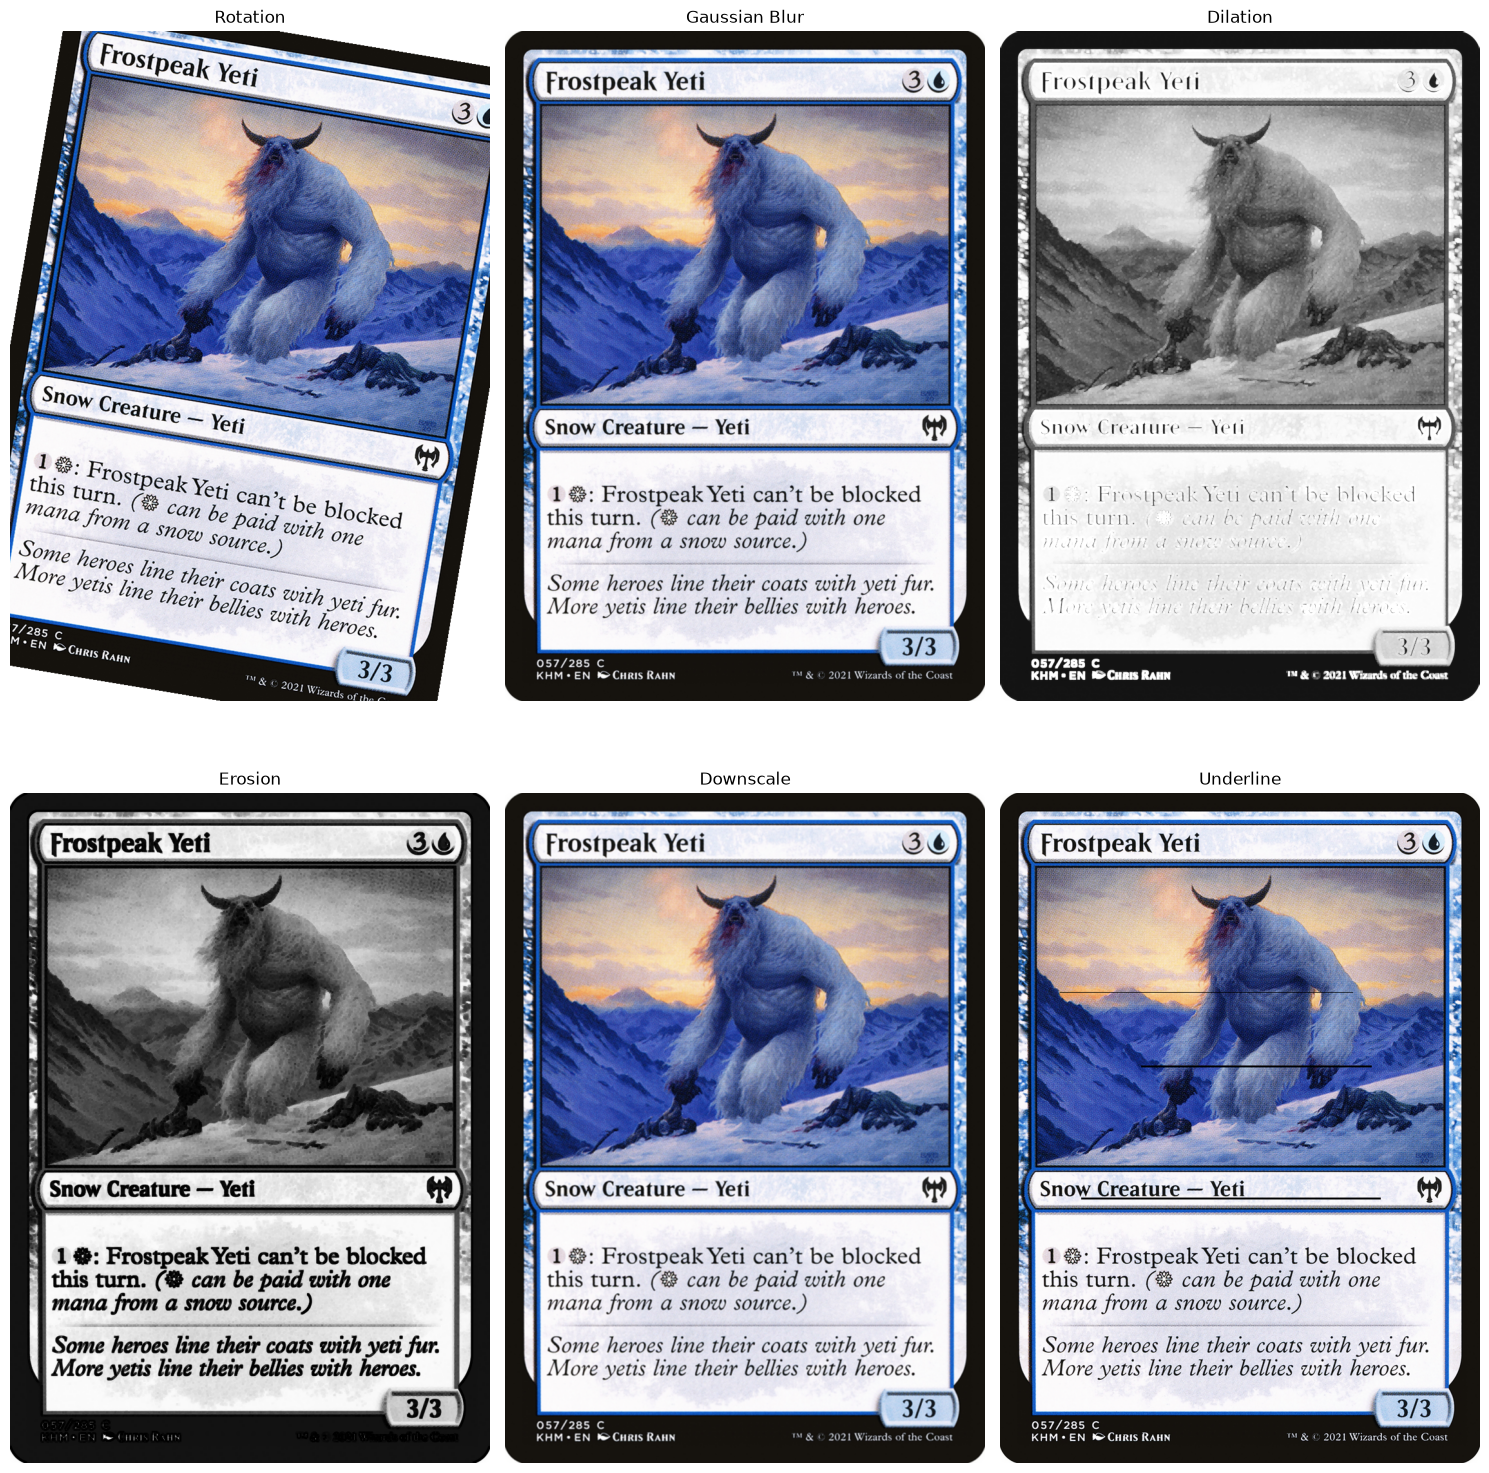

In [11]:
base_aug = OCRAugmentationConfig(
    rotation_probability=0.0,
    blur_probability=0.0,
    dilation_probability=0.0,
    erosion_probability=0.0,
    downscale_probability=0.0,
    underline_probability=0.0,
)

augmentation_previews = {
    "rotation": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"rotation_probability": 1.0}))),
    "gaussian blur": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"blur_probability": 1.0}))),
    "dilation": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"dilation_probability": 1.0}))),
    "erosion": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"erosion_probability": 1.0}))),
    "downscale": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"downscale_probability": 1.0}))),
    "underline": CardOCRAugmenter(OCRAugmentationConfig(**(base_aug.__dict__ | {"underline_probability": 1.0}))),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 16))
for axis, (name, augmenter) in zip(axes.flatten(), augmentation_previews.items(), strict=False):
    axis.imshow(augmenter(preview_image.copy(), rng=random.Random(42)))
    axis.set_title(name.title())
    axis.axis("off")
plt.tight_layout()
plt.show()

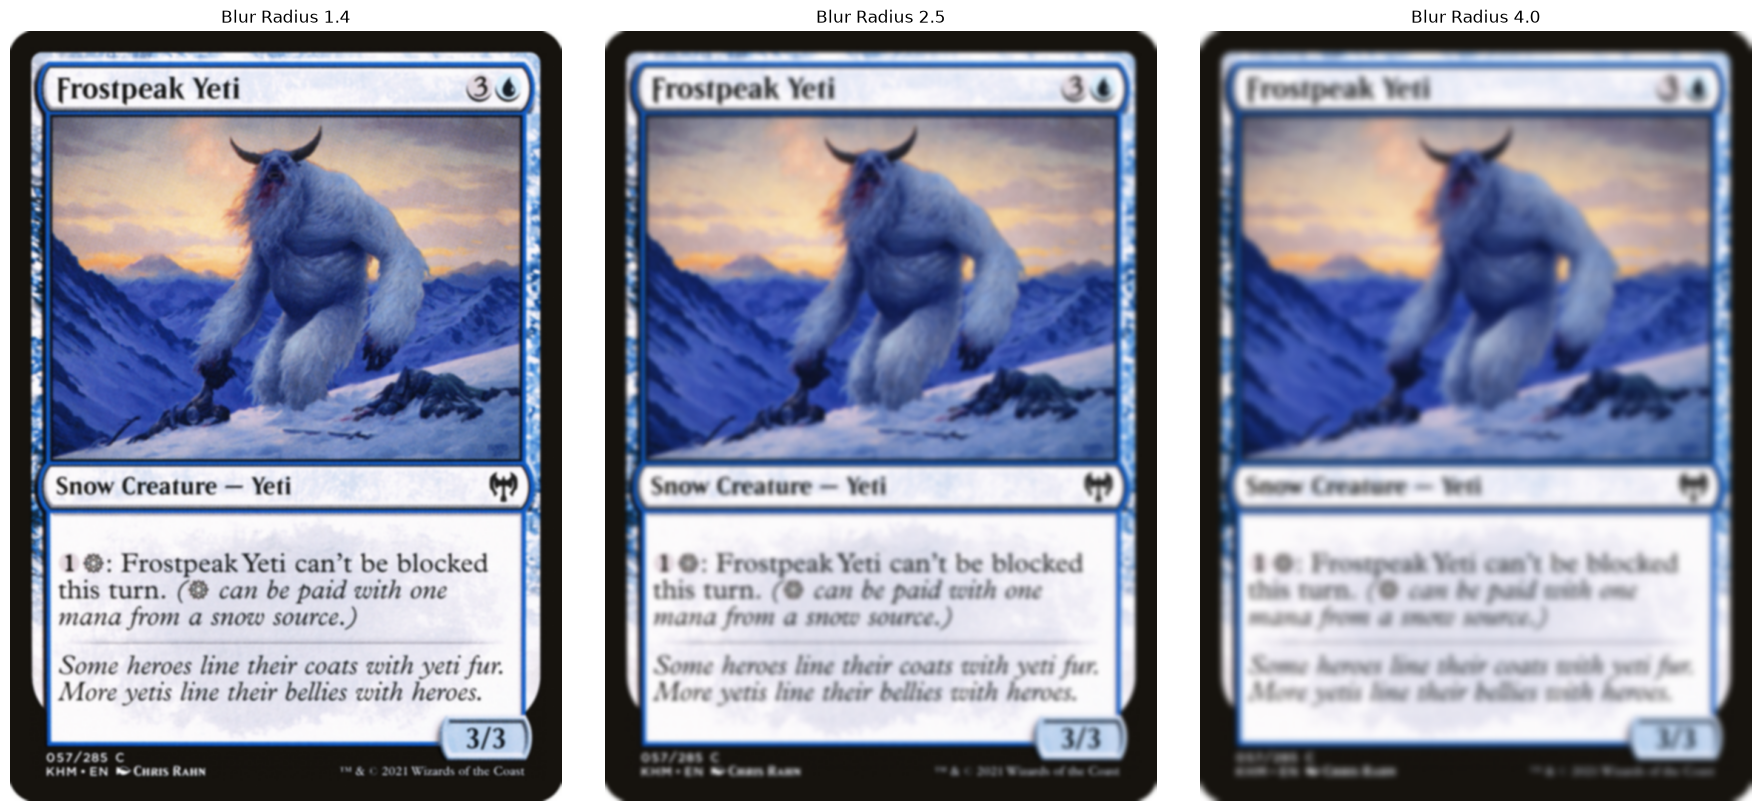

In [12]:
blur_strengths = {
    "blur radius 1.4": OCRAugmentationConfig(**(base_aug.__dict__ | {
        "blur_probability": 1.0,
        "blur_radius_min": 1.4,
        "blur_radius_max": 1.4,
    })),
    "blur radius 2.5": OCRAugmentationConfig(**(base_aug.__dict__ | {
        "blur_probability": 1.0,
        "blur_radius_min": 2.5,
        "blur_radius_max": 2.5,
    })),
    "blur radius 4.0": OCRAugmentationConfig(**(base_aug.__dict__ | {
        "blur_probability": 1.0,
        "blur_radius_min": 4.0,
        "blur_radius_max": 4.0,
    })),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for axis, (name, blur_config) in zip(axes, blur_strengths.items(), strict=False):
    blurred_image = CardOCRAugmenter(blur_config)(preview_image.copy(), rng=random.Random(42))
    axis.imshow(blurred_image)
    axis.set_title(name.title())
    axis.axis("off")
plt.tight_layout()
plt.show()

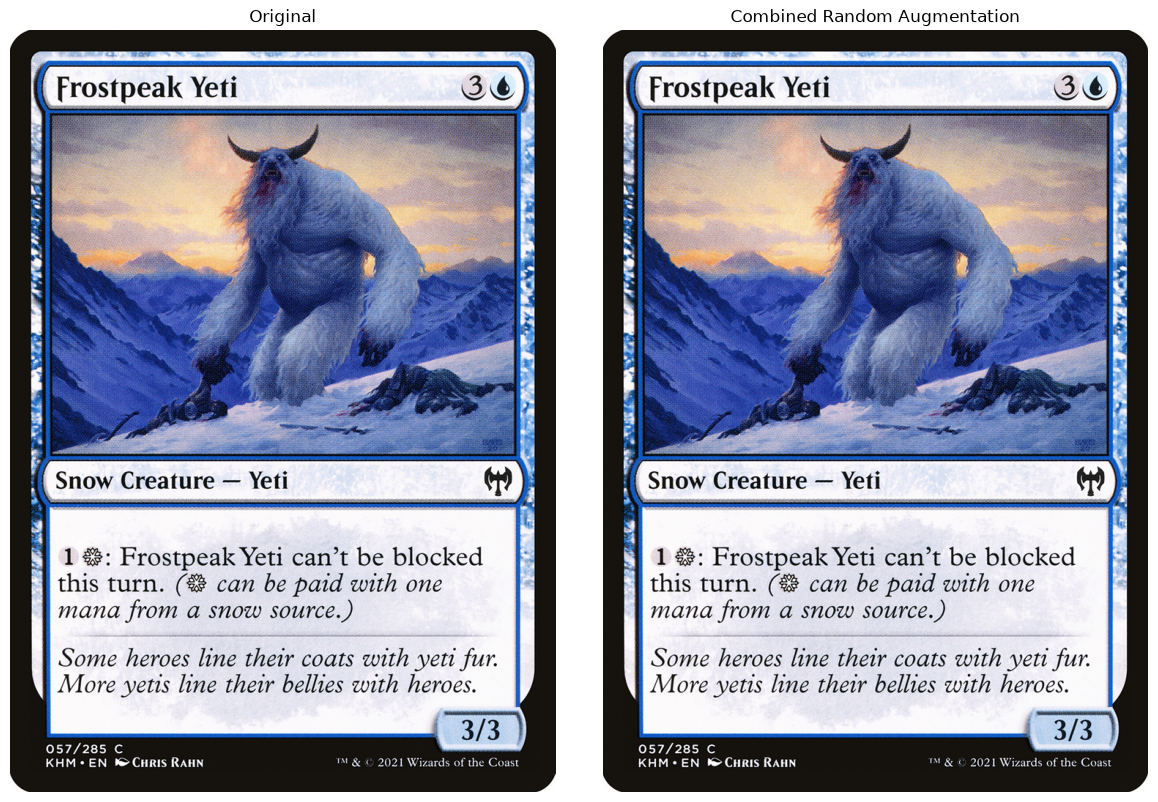

In [13]:
combined_augmenter = CardOCRAugmenter(OCRAugmentationConfig())
combined_preview = combined_augmenter(preview_image.copy(), rng=random.Random())

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(preview_image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(combined_preview)
axes[1].set_title("Combined Random Augmentation")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Base TrOCR Baseline

Before fine-tuning, these cells run the base `microsoft/trocr-small-printed` checkpoint on a few random card images so you can see how far the pretrained OCR is from the structured target format.

In [14]:
baseline_processor = TrOCRProcessor.from_pretrained(config.base_model_name)
baseline_processor.image_processor.do_resize = False
baseline_model = VisionEncoderDecoderModel.from_pretrained(config.base_model_name)
baseline_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model.to(baseline_device)
baseline_model.eval()
str(baseline_device)

Loading weights: 100%|██████████| 360/360 [00:00<00:00, 22586.11it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


'cpu'

In [15]:
baseline_records = random.sample(
    [record for record in records if Path(record["image_path"]).exists()],
    k=5,
)
[(record["card_name"], record["split"]) for record in baseline_records]

[('Gisa and Geralf', 'train'),
 ('Basal Sliver', 'val'),
 ('Devoted Paladin', 'val'),
 ('Compelled Duel', 'train'),
 ('Temple of Abandon', 'train')]

In [16]:
def run_base_ocr(record):
    with Image.open(record["image_path"]) as image:
        image = image.convert("RGB")
        image = image.resize((config.image_width, config.image_height), resample=Image.Resampling.BICUBIC)

    pixel_values = baseline_processor(images=image, return_tensors="pt").pixel_values.to(baseline_device)
    with torch.no_grad():
        generated_ids = baseline_model.generate(
            pixel_values,
            max_length=config.generation_max_length,
            num_beams=config.generation_num_beams,
            interpolate_pos_encoding=config.interpolate_pos_encoding,
        )

    prediction = baseline_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return prediction


baseline_rows = []
for record in baseline_records:
    baseline_rows.append(
        {
            "card_name": record["card_name"],
            "split": record["split"],
            "target_text": record["target_text"],
            "base_prediction": run_base_ocr(record),
        }
    )

baseline_df = pd.DataFrame(baseline_rows)
baseline_df[["card_name", "split", "target_text", "base_prediction"]]

,card_name,split,target_text,base_prediction
0,Gisa and Geralf,train,Gisa and Geralf\n Mana Cost = {2}{U}{B}...,TAX
1,Basal Sliver,val,Basal Sliver\n Mana Cost = {2}{B}\nMana...,*
2,Devoted Paladin,val,Devoted Paladin\n Mana Cost = {4}{W}\nM...,TAX
3,Compelled Duel,train,Compelled Duel\n Mana Cost = {1}{G}\nMa...,X
4,Temple of Abandon,train,Temple of Abandon\n Mana Cost =\nMana V...,INV


In [17]:
for i, row in enumerate(baseline_df.itertuples(index = False)):
    header = f'[{i+1}/{len(baseline_df)}] --- {row.card_name} (split = {row.split}) ---'
    print(f'\n{"-" * len(header)}\n{header}\n{"-" * len(header)}\n')
    print(f'Target Text = {row.target_text}\n')
    print(f'Base Prediction = {row.base_prediction}\n')
    print(f'\n{"-" * len(header)}\n')


---------------------------------------------
[1/5] --- Gisa and Geralf (split = train) ---
---------------------------------------------

Target Text = Gisa and Geralf
        Mana Cost = {2}{U}{B}
Mana Value = 4.0

        Type Line = Legendary Creature — Human Wizard

        Rules Text = When Gisa and Geralf enters, mill four cards.
Once during each of your turns, you may cast a Zombie creature spell from your graveyard.

        Power = 4
Toughness = 4


        Color Identity = ['B', 'U']

        Rarity = rare

Base Prediction = TAX


---------------------------------------------


----------------------------------------
[2/5] --- Basal Sliver (split = val) ---
----------------------------------------

Target Text = Basal Sliver
        Mana Cost = {2}{B}
Mana Value = 3.0

        Type Line = Creature — Sliver

        Rules Text = All Slivers have "Sacrifice this permanent: Add {B}{B}."

        Power = 2
Toughness = 2


        Color Identity = ['B']

        Rarity = common

## Tiny Overfit Scaffold

This is a fast sanity-check setup for memorizing a very small subset before committing to the full run. If the model cannot overfit 8-16 examples, something is probably off in the pipeline.

In [18]:
fine_tuner = CardOCRFineTuner(config)
len(fine_tuner.train_dataset), len(fine_tuner.eval_dataset), len(fine_tuner.test_dataset)

Loading weights: 100%|██████████| 360/360 [00:00<00:00, 22558.11it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 860,160 || all params: 62,456,832 || trainable%: 1.3772


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


(6713, 1680, 50)

In [19]:
batch = fine_tuner.data_collator([fine_tuner.train_dataset[0]])
{key: value.shape if hasattr(value, "shape") else value for key, value in batch.items()}

{'pixel_values': torch.Size([1, 3, 576, 800]),
 'labels': torch.Size([1, 78]),
 'interpolate_pos_encoding': True}

In [20]:
fine_tuner.model.print_trainable_parameters()

trainable params: 860,160 || all params: 62,456,832 || trainable%: 1.3772


In [21]:
tiny_config = CardOCRTrainingConfig(
    manifest_path=str(manifest_path),
    base_model_name=config.base_model_name,
    output_dir="../models/scryfall-card-ocr-tiny-overfit",
    image_height=config.image_height,
    image_width=config.image_width,
    interpolate_pos_encoding=config.interpolate_pos_encoding,
    max_target_length=config.max_target_length,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=1,
    num_train_epochs=30,
    learning_rate=5e-4,
    save_total_limit=1,
)

tiny_overfit_tuner = CardOCRFineTuner(tiny_config)
tiny_train_indices = list(range(16))
tiny_eval_indices = list(range(8))
tiny_overfit_tuner.train_dataset = Subset(tiny_overfit_tuner.train_dataset, tiny_train_indices)
tiny_overfit_tuner.eval_dataset = Subset(tiny_overfit_tuner.eval_dataset, tiny_eval_indices)
tiny_overfit_tuner.trainer = tiny_overfit_tuner._build_trainer()
len(tiny_overfit_tuner.train_dataset), len(tiny_overfit_tuner.eval_dataset)

Loading weights: 100%|██████████| 360/360 [00:00<00:00, 23103.46it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 860,160 || all params: 62,456,832 || trainable%: 1.3772


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


(16, 8)

In [22]:
# Uncomment for a tiny overfit sanity check.
tiny_overfit_result = tiny_overfit_tuner.train()
tiny_overfit_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.
/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Exact Match,Normalized Exact Match,Cer,Wer
1,No log,9.264812,0.000000,0.000000,0.997159,1.000000
2,10.659225,8.338022,0.000000,0.000000,1.248442,2.057870
3,8.965337,7.814457,0.000000,0.000000,5.727329,6.429372
4,8.038080,7.329961,0.000000,0.000000,4.476060,5.088159


/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/nickcruickshank/Projects/scryfall-llm-sandbox/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=32, training_loss=9.113947987556458, metrics={'train_runtime': 316.7316, 'train_samples_per_second': 1.515, 'train_steps_per_second': 0.758, 'total_flos': 2.43815461945344e+16, 'train_loss': 9.113947987556458, 'epoch': 4.0})

## Tiny Overfit Prediction Audit

Run these cells after the tiny training job to inspect a few train and eval examples directly.

In [23]:
tiny_train_records = [tiny_overfit_tuner.train_records[idx] for idx in tiny_train_indices]
tiny_eval_records = [tiny_overfit_tuner.eval_records[idx] for idx in tiny_eval_indices]

def preview_tiny_predictions(records, sample_size=3):
    rows = []
    for record in records[:sample_size]:
        with Image.open(record["image_path"]) as image:
            image = image.convert("RGB")

        prediction = tiny_overfit_tuner.generate_from_image(image)
        rows.append(
            {
                "card_name": record["card_name"],
                "split": record["split"],
                "target_text": record["target_text"],
                "prediction": prediction,
            }
        )
    return pd.DataFrame(rows)


In [24]:
train_audit_df = preview_tiny_predictions(tiny_train_records, sample_size=3)
train_audit_df[["card_name", "target_text", "prediction"]]

,card_name,target_text,prediction
0,Ascended Lawmage,Ascended Lawmage\n Mana Cost = {2}{W}{U...,TOTAL
1,Kami of Transmutation,Kami of Transmutation\n Mana Cost = {1}...,X
2,Felidar Umbra,Felidar Umbra\n Mana Cost = {1}{W}\nMan...,T


In [25]:
eval_audit_df = preview_tiny_predictions(tiny_eval_records, sample_size=3)
eval_audit_df[["card_name", "target_text", "prediction"]]

,card_name,target_text,prediction
0,Instill Infection,Instill Infection\n Mana Cost = {3}{B}\...,X
1,Revered Unicorn,Revered Unicorn\n Mana Cost = {1}{W}\nM...,TAX
2,Howling Gale,Howling Gale\n Mana Cost = {1}{G}\nMana...,ITEM


In [26]:
# Uncomment when you're ready to train the full model.
# train_result = fine_tuner.train()
# train_result

In [27]:
# Optional evaluation after training.
# fine_tuner.evaluate()

In [28]:
# Example inference after training.
# prediction = fine_tuner.generate_from_image(sample_image)
# print(prediction)